# Phân đoạn Tiếng nói / Khoảng lặng bằng Thống kê đơn giản (Simple Statistics)

**Sinh viên:** Nguyễn Hoàng Hiếu – MSSV 102240135

Notebook này trình bày toàn bộ quy trình phân đoạn tiếng nói (speech) / khoảng lặng (silence) dựa trên đặc trưng năng lượng ngắn hạn (STE).

**Quy trình:**
1. **Huấn luyện:** Đọc các tín hiệu huấn luyện, chia khung và tính STE, gán nhãn từng khung theo file `.lab`. Ước lượng phân bố chuẩn (μ, σ) của STE cho 2 lớp *Speech* và *Silence*, sau đó tìm ngưỡng tối ưu **T** là giao điểm của 2 phân bố chuẩn.
2. **Kiểm thử:** Áp dụng ngưỡng T lên các tín hiệu kiểm thử, hậu xử lý (xóa khoảng lặng < 200 ms), trích xuất biên thời gian, so sánh với biên chuẩn (MAE, RMSE) và vẽ đồ thị so sánh.

In [1]:
import os
import wave
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

%matplotlib inline

## 1. Tham số & Cấu hình
Khai báo các tham số cố định của thuật toán và đường dẫn dữ liệu.

In [2]:
# Tham số cố định
FRAME_LEN_MS = 25       # Độ dài khung: 25ms
FRAME_SHIFT_MS = 10     # Độ dịch khung: 10ms
MIN_SILENCE_MS = 200    # Khoảng lặng tối thiểu: 200ms

# Thư mục dữ liệu (tự dò ở thư mục hiện tại hoặc thư mục cha)
BASE_DIR = next((d for d in ['.', '..'] if os.path.isdir(os.path.join(d, 'TinHieuHuanLuyen'))), '.')
TRAIN_DIR = os.path.join(BASE_DIR, 'TinHieuHuanLuyen')
TEST_DIR = os.path.join(BASE_DIR, 'TinHieuKiemThu')

print("Thư mục huấn luyện:", os.path.abspath(TRAIN_DIR))
print("Thư mục kiểm thử  :", os.path.abspath(TEST_DIR))

Thư mục huấn luyện: C:\Users\hieu8\OneDrive\Desktop\XLTHS\GiuaKy\XLTHS\TinHieuHuanLuyen
Thư mục kiểm thử  : C:\Users\hieu8\OneDrive\Desktop\XLTHS\GiuaKy\XLTHS\TinHieuKiemThu


## 2. Các hàm xử lý chính
Các hàm đọc file, trích xuất đặc trưng (STE, ZCR, F0), tìm ngưỡng, hậu xử lý, trích xuất biên và tính sai số.

In [3]:
def readAudio(path):
    """Get the data of an .wav file for further processes (normalized Signal, sample rate, time axis)"""
    with wave.open(path, 'rb') as WavFile:
        SampleRate = WavFile.getframerate()            #how many samples are there in an amount of time aka frequency
        SampleAmount = WavFile.getnframes()            #how many samples are there 
        RawData = WavFile.readframes(SampleAmount)    #raw strings of all samples in 16 bit format

        #read the raw string in 16 bit, as conventional .wav files are saved in 16 bit format
        #this is to ensure that numpy read the raw data correctly
        Signal = np.frombuffer(RawData, dtype=np.int16)

        #normalize the amp to range of -1 to 1
        MaxAmp = np.max(np.abs(Signal))
        if MaxAmp > 0:
            SignalNormalized = Signal / MaxAmp
        else:
            SignalNormalized = Signal                  #in case Signal file is empty so that it doesnt crash

        Duration = SampleAmount / SampleRate
        TimeAxis = np.linspace(0, Duration, num=SampleAmount)

        return SignalNormalized, SampleRate, TimeAxis

def read_lab_file(lab_path):
    """
    Chức năng: Đọc file .lab và trích xuất các mốc thời gian của từng nhãn.
    Đầu vào: lab_path (string) - Đường dẫn tới file .lab
    Đầu ra: intervals (list) - Danh sách các tuple (start_time, end_time, label)
    """
    intervals = []
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3 and parts[0] not in ['F0mean', 'F0std']:
                start, end, label = float(parts[0]), float(parts[1]), parts[2]
                intervals.append((start, end, label))
    return intervals

def get_frame_label(time_sec, intervals):
    """
    Chức năng: Gán nhãn cho 1 khung dựa vào mốc thời gian so với dữ liệu .lab
    Đầu vào: time_sec (float), intervals (list)
    Đầu ra: int - 0 (Khoảng lặng), 1 (Tiếng nói)
    """
    for start, end, label in intervals:
        if start <= time_sec <= end:
            return 0 if label == 'sil' else 1
    return 0

def extract_features(signal, fs):
    """
    Chức năng: Chia khung, tính đặc trưng STE và ZCR (đã chuẩn hóa).
    Đầu vào: signal (numpy array), fs (int)
    Đầu ra: ste, zcr, times (numpy arrays)
    """
    frame_len = int(fs * FRAME_LEN_MS / 1000)
    frame_shift = int(fs * FRAME_SHIFT_MS / 1000)
    num_frames = int(np.ceil(len(signal) / frame_shift))
    
    ste = np.zeros(num_frames)
    zcr = np.zeros(num_frames)
    times = np.zeros(num_frames)
    window = np.hamming(frame_len)
    
    # Duyệt từng khung, áp dụng cửa sổ và tính toán đặc trưng
    for i in range(num_frames):
        start_idx = i * frame_shift
        end_idx = min(start_idx + frame_len, len(signal))
        frame = signal[start_idx:end_idx]
        
        if len(frame) < frame_len:
            frame = np.pad(frame, (0, frame_len - len(frame)), 'constant')
            
        frame = frame * window
        ste[i] = np.sum(frame ** 2)
        zcr[i] = np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * frame_len)
        times[i] = start_idx / fs
        
    if np.max(ste) > 0: ste = ste / np.max(ste)
    if np.max(zcr) > 0: zcr = zcr / np.max(zcr)
    
    return ste, zcr, times

def calculate_f0_autocorr(signal, fs):
    """
    Chức năng: Trích xuất F0 bằng phương pháp Tự tương quan.
    Đầu vào: signal (numpy array), fs (int)
    Đầu ra: f0, t_f0 (numpy arrays)
    """
    frame_len = int(fs * FRAME_LEN_MS / 1000)
    frame_shift = int(fs * FRAME_SHIFT_MS / 1000)
    num_frames = int(np.ceil(len(signal) / frame_shift))
    
    f0 = np.zeros(num_frames)
    t_f0 = np.zeros(num_frames)
    min_lag = int(fs / 400)
    max_lag = int(fs / 70)
    
    # Tính tự tương quan để tìm chu kỳ tuần hoàn (đỉnh của hàm tự tương quan)
    for i in range(num_frames):
        start = i * frame_shift
        end = min(start + frame_len, len(signal))
        frame = signal[start:end]
        
        if len(frame) == frame_len:
            corr = np.correlate(frame, frame, mode='full')
            corr = corr[len(corr)//2:] 
            if len(corr) > max_lag:
                peak_idx = np.argmax(corr[min_lag:max_lag]) + min_lag
                f0[i] = fs / peak_idx
        t_f0[i] = start / fs
        
    f0 = np.where(f0 > 400, 0, f0)
    return f0, t_f0

def find_intersection(mu1, std1, mu2, std2):
    """
    Chức năng: Tìm ngưỡng phân loại bằng cách giải phương trình giao điểm 2 phân bố chuẩn.
    Đầu vào: Trung bình và độ lệch chuẩn của 2 nhóm (float)
    Đầu ra: Ngưỡng tối ưu (float)
    """
    a = 1.0/(2*std1**2) - 1.0/(2*std2**2)
    b = mu2/(std2**2) - mu1/(std1**2)
    c = mu1**2 /(2*std1**2) - mu2**2 /(2*std2**2) - np.log(std2/std1)
    
    roots = np.roots([a, b, c])
    for root in roots:
        if min(mu1, mu2) <= root <= max(mu1, mu2):
            return root
    return roots[0]

def smooth_boundaries(flags, min_sil_frames):
    """
    Chức năng: Xóa các khoảng lặng và tiếng nói ảo quá ngắn (hậu xử lý).
    Đầu vào: cờ nhãn ban đầu (numpy array), số khung tối thiểu (int)
    Đầu ra: cờ nhãn đã mượt (numpy array)
    """
    smoothed = flags.copy()
    
    # 1. Xóa các điểm 1 đơn độc
    for i in range(1, len(smoothed) - 1):
        if smoothed[i-1] == 0 and smoothed[i] == 1 and smoothed[i+1] == 0:
            smoothed[i] = 0
            
    # 2. Hợp nhất các khoảng 0 (Silence) ngắn hơn 200ms thành Speech (1)
    zero_count = 0
    zero_start = -1
    for i in range(len(smoothed)):
        if smoothed[i] == 0:
            if zero_count == 0: zero_start = i
            zero_count += 1
        else:
            if 0 < zero_count < min_sil_frames:
                smoothed[zero_start:i] = 1
            zero_count = 0
            
    if 0 < zero_count < min_sil_frames:
        smoothed[zero_start:len(smoothed)] = 1
        
    return smoothed

def get_true_speech_boundaries(intervals):
    """
    Chức năng: Gộp v và uv thành 1 đoạn Speech liên tục để lấy biên thực tế (đỏ).
    Đầu vào: intervals (list)
    Đầu ra: Danh sách các mốc thời gian bắt đầu/kết thúc Speech (list)
    """
    bounds = []
    is_speech = False
    for start, end, label in intervals:
        if label != 'sil':
            if not is_speech:
                bounds.append(start)  # Bắt đầu Speech
                is_speech = True
        else:
            if is_speech:
                bounds.append(start)  # Kết thúc Speech
                is_speech = False
    if is_speech:
        bounds.append(intervals[-1][1])
    return bounds

def get_pred_boundaries(flags, times):
    """
    Chức năng: Lấy các mốc thời gian chuyển trạng thái từ mảng cờ nhãn (biên dự đoán - xanh).
    Đầu vào: flags (numpy array 0/1), times (numpy array)
    Đầu ra: Danh sách các mốc thời gian bắt đầu/kết thúc Speech (list)
    """
    diff = np.diff(np.insert(flags, 0, 0))
    pred_bounds = [times[i] for i, d in enumerate(diff) if d == 1 or d == -1]
    if flags[-1] == 1: pred_bounds.append(times[-1])
    return pred_bounds

def calculate_errors(true_bounds, pred_bounds):
    """
    Chức năng: Tính sai số MAE và RMSE (bằng ms) bằng thuật toán ghép cặp (Nearest Neighbor).
    Đầu vào: true_bounds (biên đỏ), pred_bounds (biên xanh)
    Đầu ra: mae, rmse (float) đơn vị mili-giây
    """
    if not true_bounds or not pred_bounds:
        return 0.0, 0.0
        
    errors = []
    for tb in true_bounds:
        # Tìm biên dự đoán (xanh) nằm gần nhất với biên thực tế (đỏ) hiện tại
        closest_pb = min(pred_bounds, key=lambda pb: abs(pb - tb))
        error_ms = abs(tb - closest_pb) * 1000 # Đổi giây sang ms
        errors.append(error_ms)
        
    errors_arr = np.array(errors)
    mae = np.mean(errors_arr)                      # Mean Absolute Error
    rmse = np.sqrt(np.mean(errors_arr ** 2))       # Root Mean Squared Error
    
    return mae, rmse

def format_segments(bounds, is_true):
    """
    Chức năng: Gom nhóm danh sách biên thành các cặp [start, end] để in ra.
    """
    segs = []
    decimals = 2 if is_true else 3
    for i in range(0, len(bounds), 2):
        s = round(float(bounds[i]), decimals)
        e = round(float(bounds[i+1]), decimals) if i+1 < len(bounds) else s
        segs.append([s, e])
    return segs

## 3. Module Huấn luyện
Tính STE cho toàn bộ tín hiệu huấn luyện, gom theo nhãn *Speech* / *Silence*, ước lượng phân bố chuẩn của mỗi lớp và tìm ngưỡng **T** tại giao điểm của 2 phân bố.

In [4]:
def train(train_dir=TRAIN_DIR):
    """
    Chức năng: Huấn luyện - tìm phân bố chuẩn của STE cho 2 lớp và ngưỡng tối ưu.
    Đầu ra: dict chứa ngưỡng, tham số phân bố và dữ liệu STE của 2 lớp
    """
    files = sorted(f for f in os.listdir(train_dir) if f.endswith('.wav'))
    if not files:
        print(f"Cảnh báo: Không tìm thấy file huấn luyện trong '{train_dir}'!")
        return None

    speech_ste, silence_ste = [], []
    for file in files:
        wav_path = os.path.join(train_dir, file)
        lab_path = os.path.join(train_dir, file.replace('.wav', '.lab'))

        signal, fs, t_sig = readAudio(wav_path)
        intervals = read_lab_file(lab_path)
        ste, _, times = extract_features(signal, fs)

        for i, t in enumerate(times):
            label = get_frame_label(t, intervals)
            if label == 1: speech_ste.append(ste[i])
            else: silence_ste.append(ste[i])
        print(f"  Đã xử lý: {file}")

    speech_ste, silence_ste = np.array(speech_ste), np.array(silence_ste)
    mu_sp, std_sp = np.mean(speech_ste), np.std(speech_ste)
    mu_sil, std_sil = np.mean(silence_ste), np.std(silence_ste)
    threshold = find_intersection(mu_sil, std_sil, mu_sp, std_sp)

    print(f"\n=> Số khung: Speech = {len(speech_ste)}, Silence = {len(silence_ste)}")
    print(f"=> Phân bố Chuẩn: Speech (μ={mu_sp:.4f}, σ={std_sp:.4f}), Silence (μ={mu_sil:.4f}, σ={std_sil:.4f})")
    print(f"=> Ngưỡng STE tối ưu (Threshold): {threshold:.4f}")
    print(f"\n[NGUONG DUNG CHUNG] T1 (STE) = {threshold:.5f} | (Dựa trên Phân bố chuẩn)")

    return {
        'threshold': threshold,
        'mu_sp': mu_sp, 'std_sp': std_sp,
        'mu_sil': mu_sil, 'std_sil': std_sil,
        'speech_ste': speech_ste, 'silence_ste': silence_ste,
    }

def gaussian_pdf(x, mu, std):
    return np.exp(-(x - mu) ** 2 / (2 * std ** 2)) / (std * np.sqrt(2 * np.pi))

def plot_training_distribution(model):
    """
    Chức năng: Vẽ histogram STE của 2 lớp, đường phân bố chuẩn ước lượng và ngưỡng tìm được.
    """
    T = model['threshold']

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    fig.suptitle('Huấn luyện: Phân bố STE của Speech và Silence', fontsize=13)

    # (a) Histogram số khung theo từng lớp
    bins = np.linspace(0, 1, 51)
    ax[0].hist(model['silence_ste'], bins=bins, alpha=0.6, color='gray', label=f"Silence ({len(model['silence_ste'])} khung)")
    ax[0].hist(model['speech_ste'], bins=bins, alpha=0.6, color='tab:orange', label=f"Speech ({len(model['speech_ste'])} khung)")
    ax[0].axvline(T, color='purple', linestyle='--', linewidth=2, label=f'Ngưỡng T = {T:.4f}')
    ax[0].set_xlim(0, 1)
    ax[0].set_title('Histogram STE theo nhãn')
    ax[0].set_xlabel('STE (đã chuẩn hóa)')
    ax[0].set_ylabel('Số khung')
    ax[0].legend(fontsize=9)
    ax[0].grid(True, alpha=0.3)

    # (b) Phân bố chuẩn ước lượng và giao điểm (ngưỡng)
    xmax = max(0.25, 4 * T)
    xx = np.linspace(0, xmax, 2000)
    pdf_sil = gaussian_pdf(xx, model['mu_sil'], model['std_sil'])
    pdf_sp = gaussian_pdf(xx, model['mu_sp'], model['std_sp'])
    ax[1].plot(xx, pdf_sil, color='black', linewidth=2,
               label=f"Silence: N(μ={model['mu_sil']:.4f}, σ={model['std_sil']:.4f})")
    ax[1].plot(xx, pdf_sp, color='red', linewidth=2,
               label=f"Speech: N(μ={model['mu_sp']:.4f}, σ={model['std_sp']:.4f})")
    ax[1].fill_between(xx, pdf_sil, where=xx <= T, color='gray', alpha=0.2)
    ax[1].fill_between(xx, pdf_sp, where=xx >= T, color='tab:orange', alpha=0.2)
    yT = gaussian_pdf(T, model['mu_sp'], model['std_sp'])
    ax[1].axvline(T, color='purple', linestyle='--', linewidth=2, label=f'Ngưỡng T = {T:.4f} (giao điểm)')
    ax[1].plot(T, yT, 'o', color='purple', markersize=8)
    ax[1].set_xlim(0, xmax)
    ax[1].set_ylim(0, 1.1 * pdf_sil.max())
    ax[1].set_title('Phân bố chuẩn ước lượng (phóng to vùng ngưỡng)')
    ax[1].set_xlabel('STE (đã chuẩn hóa)')
    ax[1].set_ylabel('Mật độ xác suất')
    ax[1].legend(fontsize=9)
    ax[1].grid(True, alpha=0.3)
    plt.show()

## 4. Module Kiểm thử
Áp dụng ngưỡng toàn cục lên các tín hiệu kiểm thử, tính MAE / RMSE và vẽ đồ thị so sánh biên thời gian.

In [5]:
def plot_results(signal, fs, t_sig, times, ste, zcr, true_bounds, pred_bounds, wav_name, threshold, mae, rmse):
    """
    Chức năng: Trực quan hóa đặc trưng trung gian, biên thời gian (chuẩn vs dự đoán) và F0.
    """
    f0, t_f0 = calculate_f0_autocorr(signal, fs)

    fig = plt.figure(figsize=(14, 6.5))
    plt.suptitle(f'Kết quả {wav_name} | MAE: {mae:.1f}ms - RMSE: {rmse:.1f}ms', fontsize=13)

    # ============ TẦNG 1: ĐẶC TRƯNG TRUNG GIAN ============
    plt.subplot(2, 1, 1)
    plt.plot(t_sig, signal, label='Normalized Signal', color='lightgray')
    plt.plot(times, ste, label='STE', color='blue', linewidth=1.5)
    plt.plot(times, zcr, label='ZCR', color='green', linewidth=1.5)
    plt.axhline(y=threshold, color='purple', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Ngưỡng ({threshold:.3f})')
    plt.title('Đặc trưng trung gian')
    plt.ylabel('Amplitude')
    plt.xlim(0, t_sig[-1])
    plt.legend(loc='upper right')
    plt.grid(True)

    # ============ TẦNG 2: SO SÁNH BIÊN VÀ F0 ============
    plt.subplot(2, 1, 2)
    plt.plot(t_sig, signal, label='Signal', color='lightgray')

    f0_plot = np.where(f0 > 0, f0, np.nan)
    f0_norm = (f0_plot - np.nanmin(f0_plot)) / (np.nanmax(f0_plot) - np.nanmin(f0_plot)) * np.max(np.abs(signal))
    plt.plot(t_f0, f0_norm, 'r.', label='F0 Contour', markersize=3)

    # Vẽ biên thực tế (ĐỎ)
    for tb in true_bounds:
        plt.axvline(x=tb, color='red', linestyle='-', linewidth=2, alpha=0.7)

    # Vẽ biên dự đoán (XANH)
    for pb in pred_bounds:
        plt.axvline(x=pb, color='blue', linestyle='-', linewidth=2)

    plt.title('So sánh biên thời gian và F0')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude / F0 (Scaled)')
    plt.xlim(0, t_sig[-1])

    red_line = mlines.Line2D([], [], color='red', linestyle='-', label='Chuẩn (Đỏ)')
    blue_line = mlines.Line2D([], [], color='blue', linestyle='-', label='Dự đoán (Xanh)')
    f0_dot = mlines.Line2D([], [], color='red', marker='.', linestyle='None', label='F0')
    plt.legend(handles=[red_line, blue_line, f0_dot], loc='upper right')

    plt.tight_layout()
    plt.show()

def test(model, test_dir=TEST_DIR):
    """
    Chức năng: Kiểm thử ngưỡng trên tập kiểm thử, in kết quả và vẽ đồ thị từng file.
    """
    threshold = model['threshold']
    min_sil_frames = int(MIN_SILENCE_MS / FRAME_SHIFT_MS)
    files = sorted(f for f in os.listdir(test_dir) if f.endswith('.wav'))
    table_data = []

    for file in files:
        wav_path = os.path.join(test_dir, file)
        lab_path = os.path.join(test_dir, file.replace('.wav', '.lab'))

        signal, fs, t_sig = readAudio(wav_path)
        intervals = read_lab_file(lab_path)
        ste, zcr, times = extract_features(signal, fs)

        flags = np.where(ste > threshold, 1, 0)
        smoothed_flags = smooth_boundaries(flags, min_sil_frames)

        true_bounds = get_true_speech_boundaries(intervals)
        pred_bounds = get_pred_boundaries(smoothed_flags, times)
        mae, rmse = calculate_errors(true_bounds, pred_bounds)

        table_data.append({
            'file': file,
            'true_count': len(true_bounds),
            'pred_count': len(pred_bounds),
            'mae': mae,
            'rmse': rmse
        })

        print(f"{file}")
        print(f"  chuan : {format_segments(true_bounds, is_true=True)}")
        print(f"  thuat toan: {format_segments(pred_bounds, is_true=False)}")

        plot_results(signal, fs, t_sig, times, ste, zcr, true_bounds, pred_bounds, file, threshold, mae, rmse)

    # Bảng tổng hợp kết quả kiểm thử
    print("\n[KIEM THU]")
    print(f"{'File':<15} {'#bien chuan':>11} {'#bien TT':>9} {'MAE(ms)':>9} {'RMSE(ms)':>9}")

    total_mae, total_rmse = 0, 0
    for row in table_data:
        print(f"{row['file']:<15} {row['true_count']:>11} {row['pred_count']:>9} {row['mae']:>9.2f} {row['rmse']:>9.2f}")
        total_mae += row['mae']
        total_rmse += row['rmse']

    if table_data:
        print(f"{'TRUNG BINH':<15} {'':>11} {'':>9} {total_mae/len(table_data):>9.2f} {total_rmse/len(table_data):>9.2f}")

    return table_data

## 5. Thực thi chính
Chạy module huấn luyện trước, sau đó kiểm thử ngay với ngưỡng vừa tìm được.

--- 1. HUẤN LUYỆN (TÌM PHÂN BỐ CHUẨN) ---
  Đã xử lý: phone_F1.wav
  Đã xử lý: phone_M1.wav
  Đã xử lý: studio_F1.wav
  Đã xử lý: studio_M1.wav

=> Số khung: Speech = 794, Silence = 507
=> Phân bố Chuẩn: Speech (μ=0.1697, σ=0.2071), Silence (μ=0.0014, σ=0.0235)
=> Ngưỡng STE tối ưu (Threshold): 0.0522

[NGUONG DUNG CHUNG] T1 (STE) = 0.05221 | (Dựa trên Phân bố chuẩn)

Đồ thị phân bố STE trên tập huấn luyện:


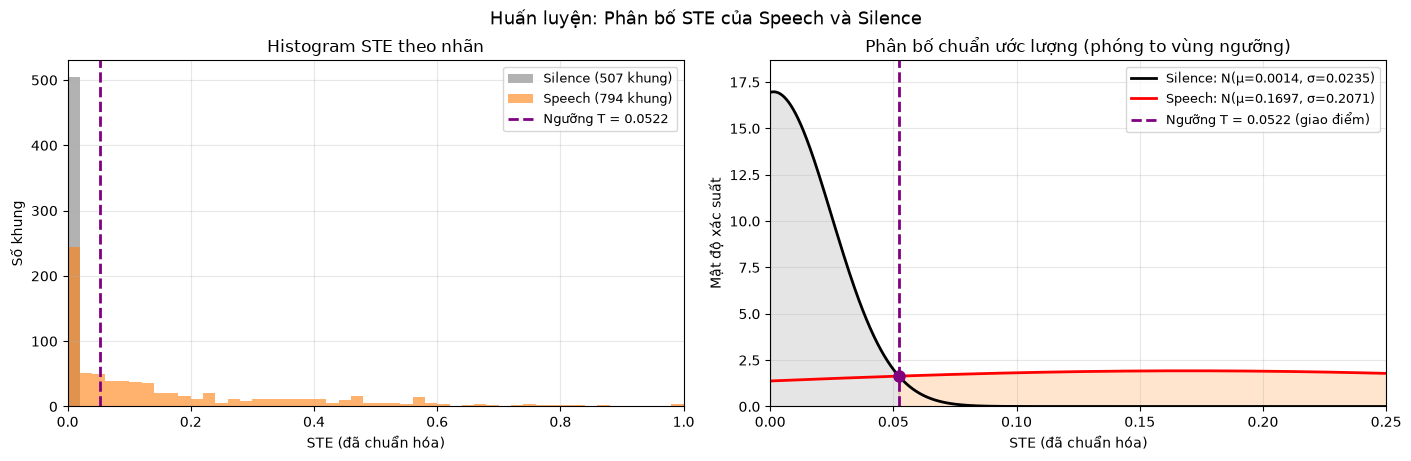


--- 2. XUẤT KẾT QUẢ KIỂM THỬ VÀ SAI SỐ ---
phone_F2.wav
  chuan : [[1.02, 4.04]]
  thuat toan: [[1.09, 2.49], [2.8, 3.44], [3.67, 3.99]]


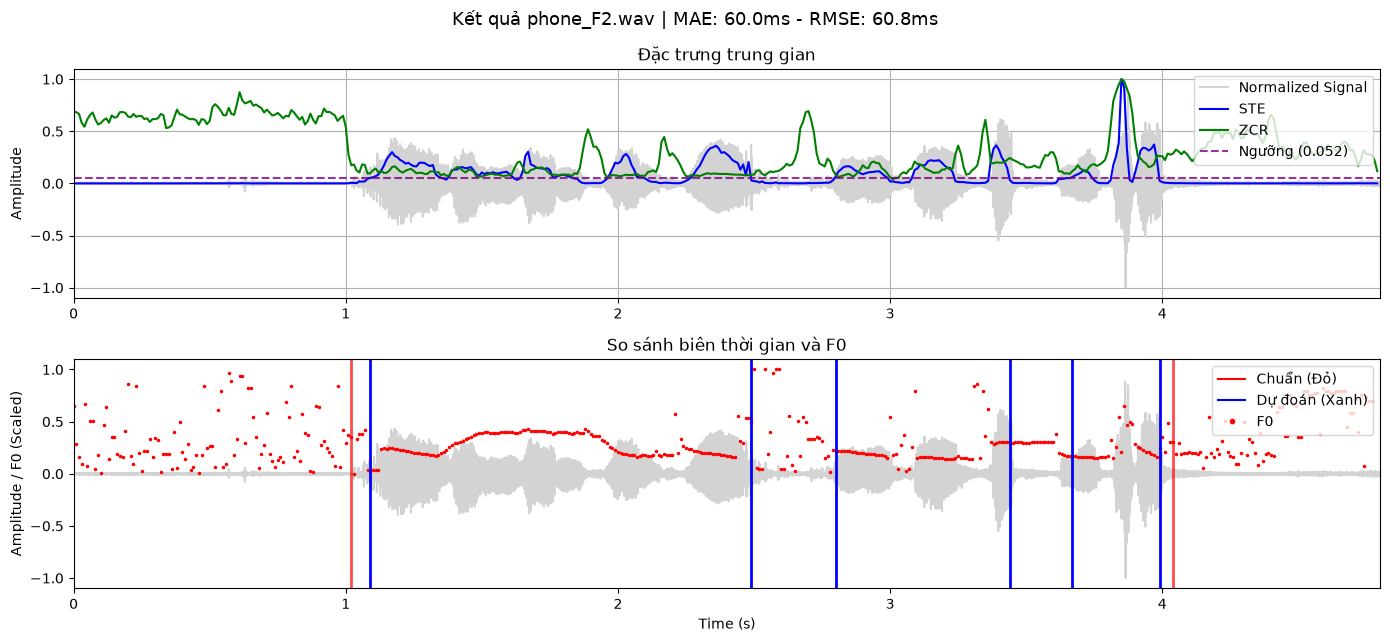

phone_M2.wav
  chuan : [[0.53, 2.52]]
  thuat toan: [[0.53, 1.46], [1.67, 2.49]]


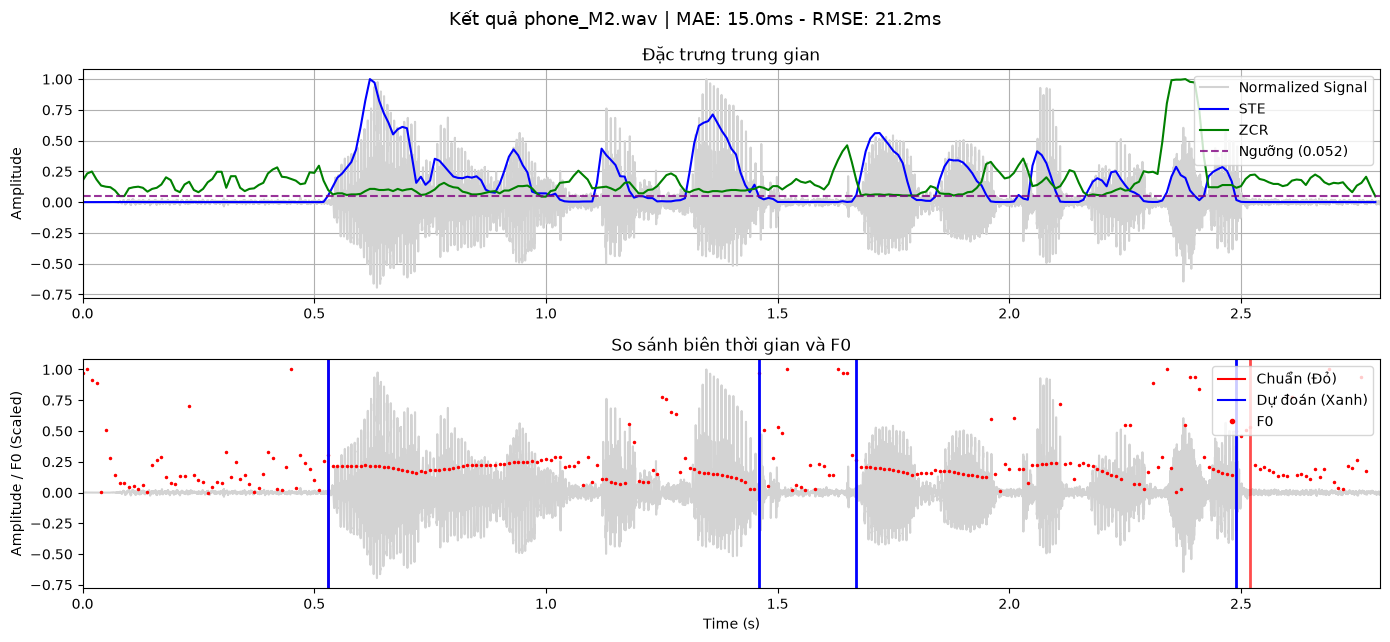

studio_F2.wav
  chuan : [[0.77, 2.37]]
  thuat toan: [[0.77, 2.29]]


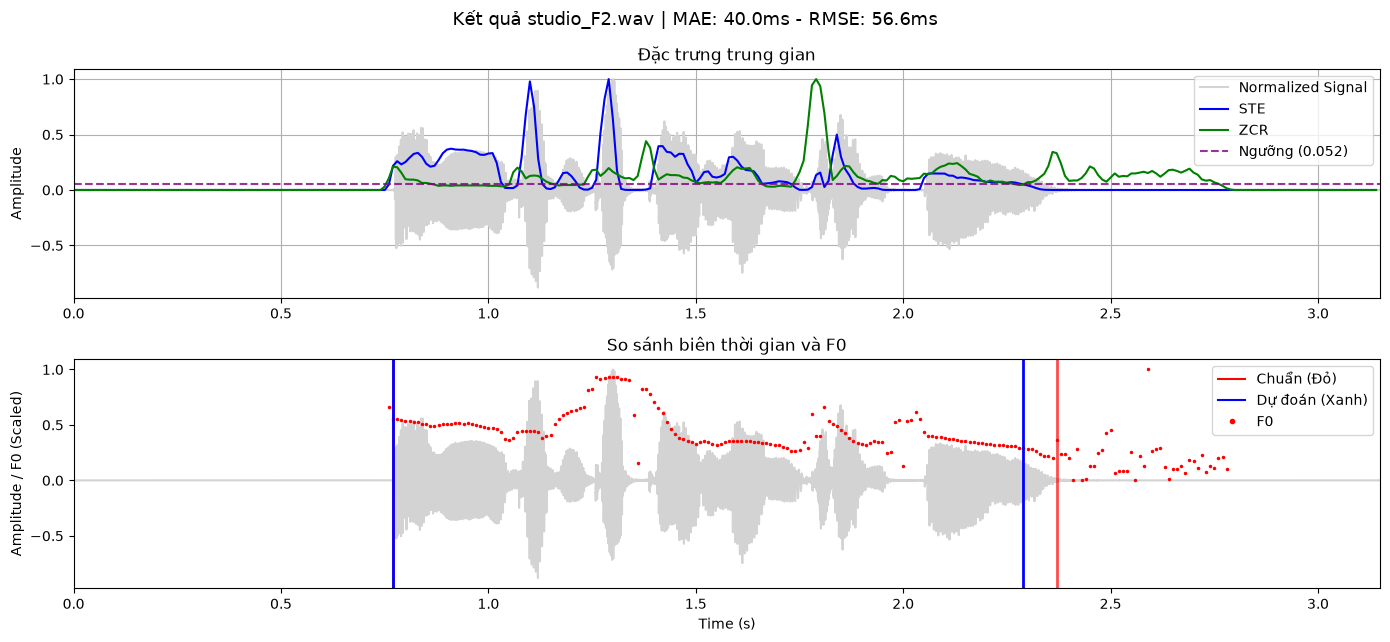

studio_M2.wav
  chuan : [[0.45, 1.93]]
  thuat toan: [[0.47, 1.88]]


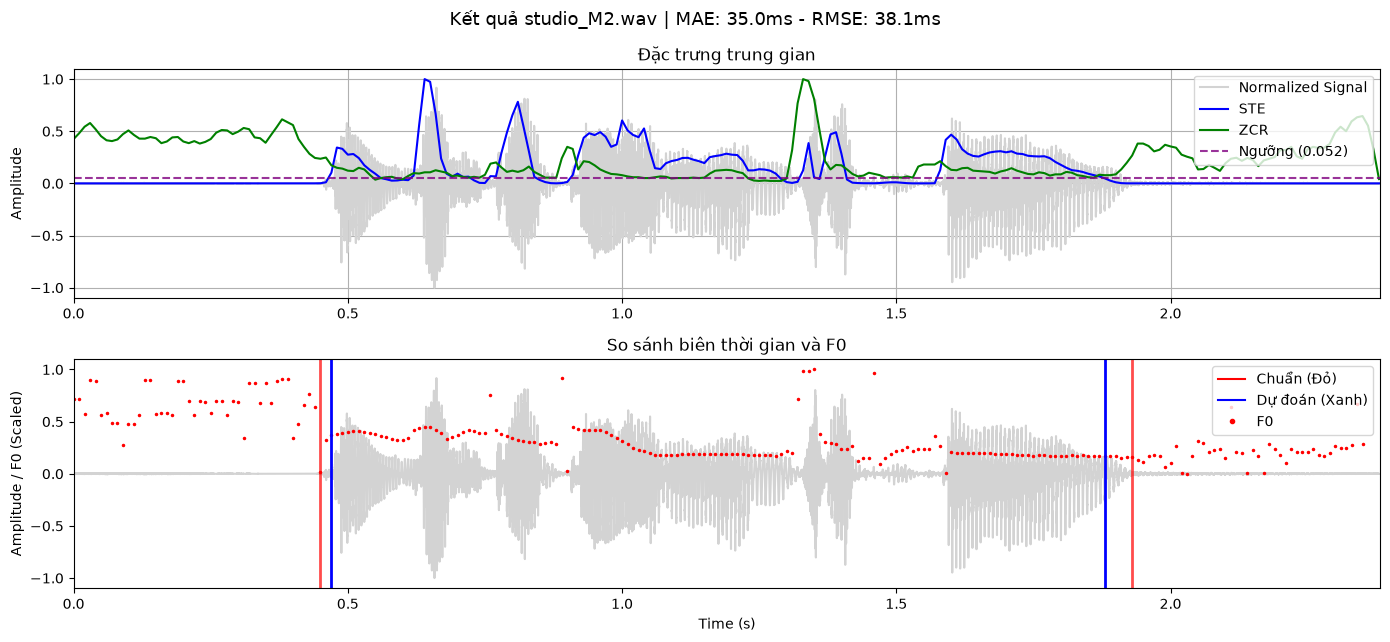


[KIEM THU]
File            #bien chuan  #bien TT   MAE(ms)  RMSE(ms)
phone_F2.wav              2         6     60.00     60.83
phone_M2.wav              2         4     15.00     21.21
studio_F2.wav             2         2     40.00     56.57
studio_M2.wav             2         2     35.00     38.08
TRUNG BINH                                37.50     44.17


In [6]:
def main():
    print("--- 1. HUẤN LUYỆN (TÌM PHÂN BỐ CHUẨN) ---")
    model = train()

    if model:
        print("\nĐồ thị phân bố STE trên tập huấn luyện:")
        plot_training_distribution(model)

        print("\n--- 2. XUẤT KẾT QUẢ KIỂM THỬ VÀ SAI SỐ ---")
        test(model)
    else:
        print("Huấn luyện thất bại. Hãy kiểm tra thư mục 'TinHieuHuanLuyen' có chứa các file .wav/.lab hợp lệ.")

if __name__ == "__main__":
    main()